# Análisis Exploratorio de los Datos (EDA)

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path

plt.style.use("default")

# =============================================================================
# RUTA PARA GUARDAR LAS FIGURAS DEL EDA
# =============================================================================

EDA_FIGURES_PATH = Path("../figures/02_eda")

EDA_FIGURES_PATH.mkdir(
    parents=True,
    exist_ok=True,
)


## 2. Carga de datos

In [2]:
DATA_PATH = Path("/home/ldominguez/master_ml/TFM_Store_Sales/data/raw")

train = pd.read_csv(DATA_PATH / "train.csv")
test = pd.read_csv(DATA_PATH / "test.csv")
stores = pd.read_csv(DATA_PATH / "stores.csv")
transactions = pd.read_csv(DATA_PATH / "transactions.csv")
oil = pd.read_csv(DATA_PATH / "oil.csv")
holidays = pd.read_csv(DATA_PATH / "holidays_events.csv")

In [3]:
train["date"] = pd.to_datetime(train["date"])
transactions["date"] = pd.to_datetime(transactions["date"])
oil["date"] = pd.to_datetime(oil["date"])
holidays["date"] = pd.to_datetime(holidays["date"])

## 3. Análisis de la variable objetivo (`sales`)

In [4]:
# =============================================================================
# Estadísticos descriptivos de la variable objetivo
# =============================================================================

display(train["sales"].describe().to_frame().T)

print(f"Media: {train['sales'].mean():.2f}")
print(f"Mediana: {train['sales'].median():.2f}")
print(f"Desviación típica: {train['sales'].std():.2f}")
print(f"Mínimo: {train['sales'].min():.2f}")
print(f"Máximo: {train['sales'].max():.2f}")

,count,mean,std,min,25%,50%,75%,max
sales,3000888.0,357.775749,1101.997721,0.0,0.0,11.0,195.84725,124717.0


Media: 357.78
Mediana: 11.00
Desviación típica: 1102.00
Mínimo: 0.00
Máximo: 124717.00


In [5]:
# =============================================================================
# Ventas iguales a cero
# =============================================================================

num_zero_sales = (train["sales"] == 0).sum()
pct_zero_sales = num_zero_sales / len(train) * 100

print(f"Número de ventas iguales a cero: {num_zero_sales:,}")
print(f"Porcentaje: {pct_zero_sales:.2f}%")

Número de ventas iguales a cero: 939,130
Porcentaje: 31.30%


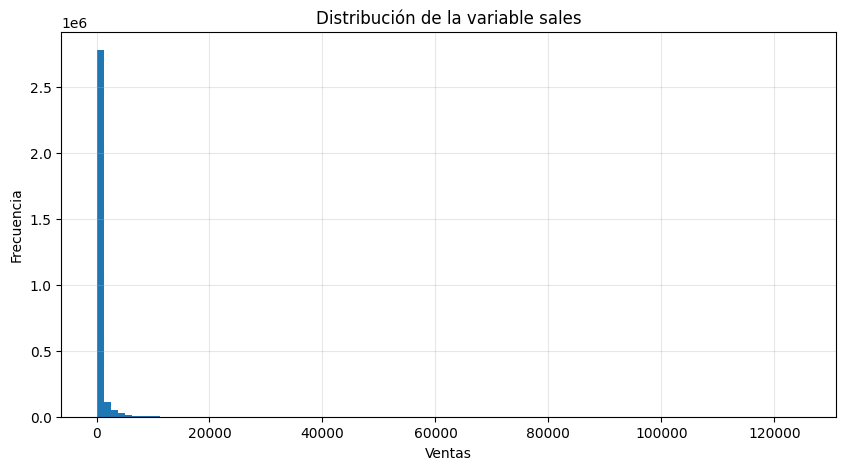

In [ ]:
# =============================================================================
# Distribución de las ventas
# =============================================================================

plt.figure(figsize=(10,5))

plt.hist(train["sales"], bins=100)

plt.title("Distribución de la variable sales")

plt.xlabel("Ventas")

plt.ylabel("Frecuencia")

plt.grid(alpha=0.3)


plt.savefig(
    EDA_FIGURES_PATH / "distribucion_sales.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

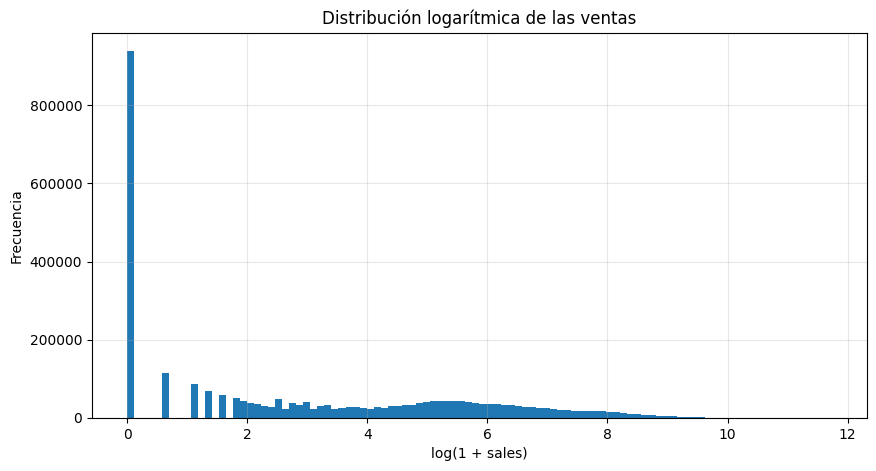

In [ ]:
# =============================================================================
# Distribución logarítmica
# =============================================================================

plt.figure(figsize=(10,5))

plt.hist(np.log1p(train["sales"]), bins=100)

plt.title("Distribución logarítmica de las ventas")

plt.xlabel("log(1 + sales)")

plt.ylabel("Frecuencia")

plt.grid(alpha=0.3)


plt.savefig(
    EDA_FIGURES_PATH / "distribucion_log_sales.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

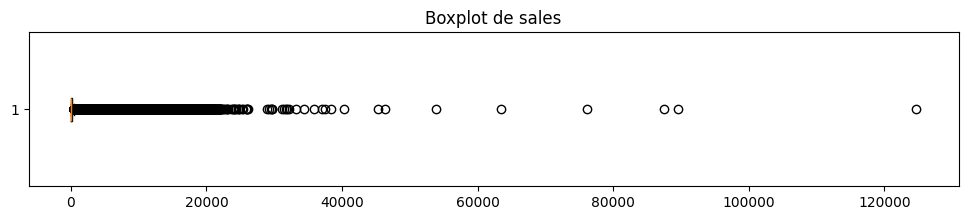

In [ ]:
# =============================================================================
# Boxplot
# =============================================================================

plt.figure(figsize=(12,2))

plt.boxplot(train["sales"], vert=False)

plt.title("Boxplot de sales")


plt.savefig(
    EDA_FIGURES_PATH / "boxplot_sales.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [9]:
# =============================================================================
# Percentiles
# =============================================================================

percentiles = train["sales"].quantile(
    [0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.999]
)

display(percentiles.to_frame(name="sales"))

,sales
0.250,0.000000
0.500,11.000000
0.750,195.847250
0.900,867.000000
0.950,1965.000000
0.990,5507.000000
0.999,12076.225548


In [10]:
### Ventas agregadas por mes y año

monthly_sales = (
    train
    .groupby(train["date"].dt.to_period("M"))["sales"]
    .sum()
)

monthly_sales.head()

date
2013-01    1.032762e+07
2013-02    9.658960e+06
2013-03    1.142850e+07
2013-04    1.099346e+07
2013-05    1.159770e+07
Freq: M, Name: sales, dtype: float64

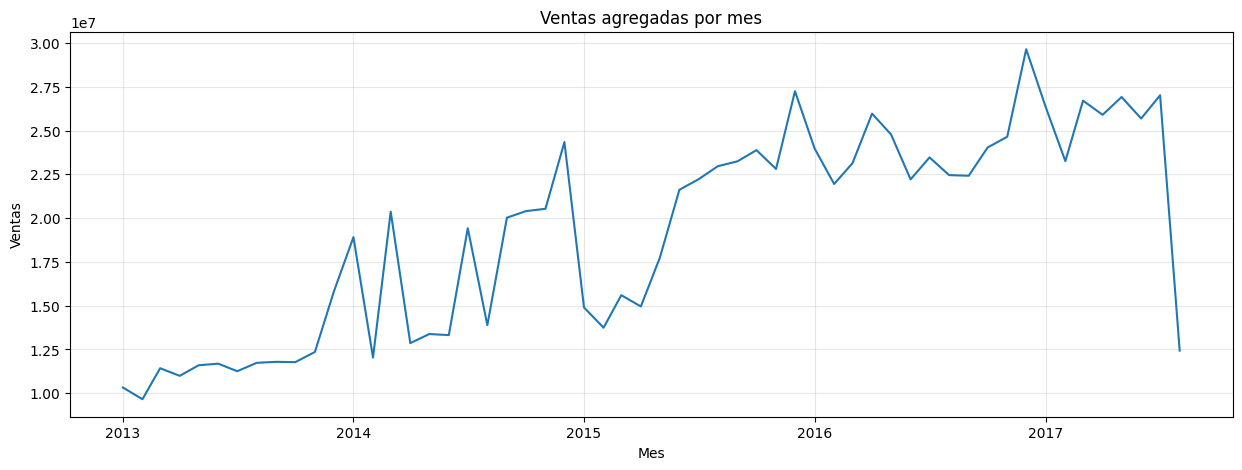

In [ ]:
monthly_sales.index = monthly_sales.index.to_timestamp()

plt.figure(figsize=(15,5))

plt.plot(monthly_sales.index,
         monthly_sales.values)

plt.title("Ventas agregadas por mes")

plt.xlabel("Mes")

plt.ylabel("Ventas")

plt.grid(alpha=0.3)


plt.savefig(
    EDA_FIGURES_PATH / "ventas_agregadas_mes.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

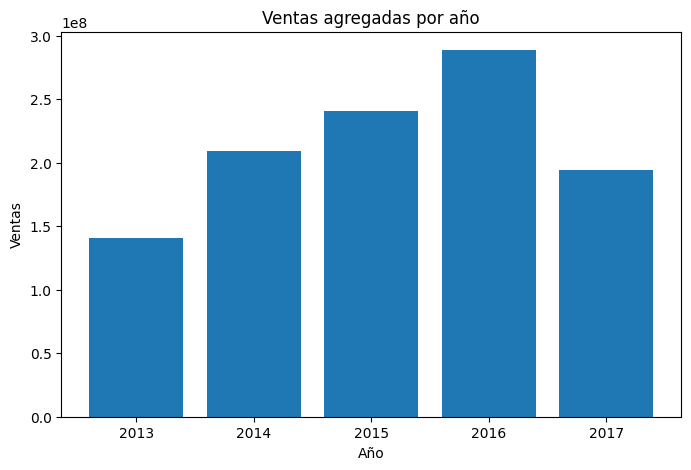

In [12]:
yearly_sales = (
    train
    .groupby(train["date"].dt.year)["sales"]
    .sum()
)

plt.figure(figsize=(8,5))

plt.bar(
    yearly_sales.index.astype(str),
    yearly_sales.values
)

plt.title("Ventas agregadas por año")

plt.xlabel("Año")

plt.ylabel("Ventas")

plt.show()

# 3.2 - Análisis temporal

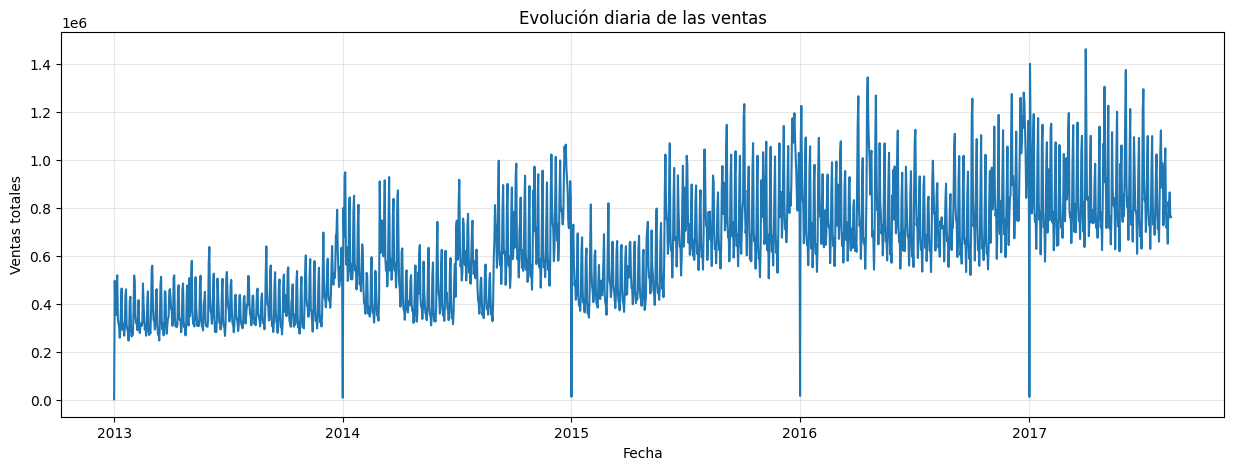

In [13]:
# =============================================================================
# Evolución diaria de las ventas
# =============================================================================

daily_sales = (
    train
    .groupby("date")["sales"]
    .sum()
)

plt.figure(figsize=(15,5))

plt.plot(daily_sales.index,
         daily_sales.values)

plt.title("Evolución diaria de las ventas")

plt.xlabel("Fecha")

plt.ylabel("Ventas totales")

plt.grid(alpha=0.3)

plt.show()

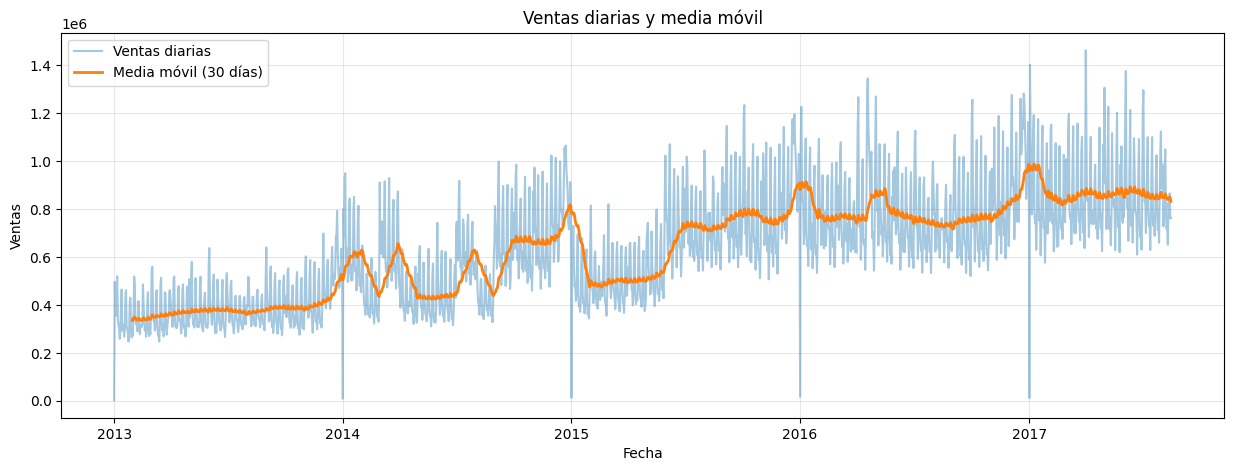

In [ ]:
rolling = daily_sales.rolling(window=30).mean()

plt.figure(figsize=(15,5))

plt.plot(
    daily_sales.index,
    daily_sales.values,
    alpha=0.4,
    label="Ventas diarias"
)

plt.plot(
    rolling.index,
    rolling.values,
    linewidth=2,
    label="Media móvil (30 días)"
)

plt.legend()

plt.title("Ventas diarias y media móvil")

plt.xlabel("Fecha")

plt.ylabel("Ventas")

plt.grid(alpha=0.3)


plt.savefig(
    EDA_FIGURES_PATH / "evolucion_ventas_media_movil.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [15]:
### Estacionalidad semanal

train["day_name"] = train["date"].dt.day_name()

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

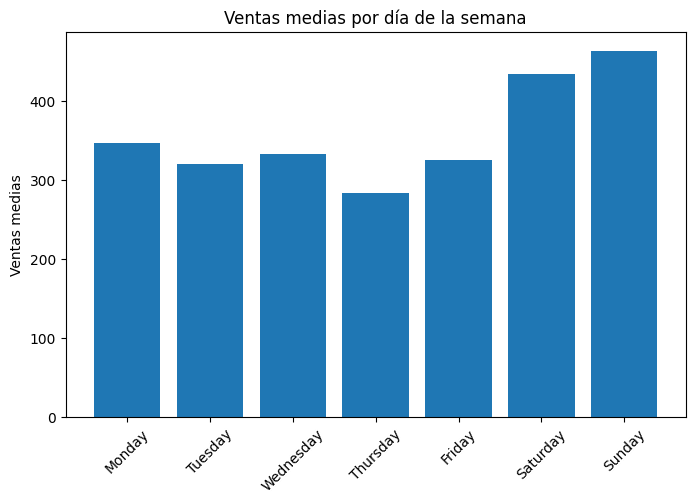

In [ ]:
weekday_sales = (
    train
    .groupby("day_name")["sales"]
    .mean()
    .reindex(weekday_order)
)

plt.figure(figsize=(8,5))

plt.bar(
    weekday_sales.index,
    weekday_sales.values
)

plt.title("Ventas medias por día de la semana")

plt.ylabel("Ventas medias")

plt.xticks(rotation=45)


plt.savefig(
    EDA_FIGURES_PATH / "ventas_dia_semana.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

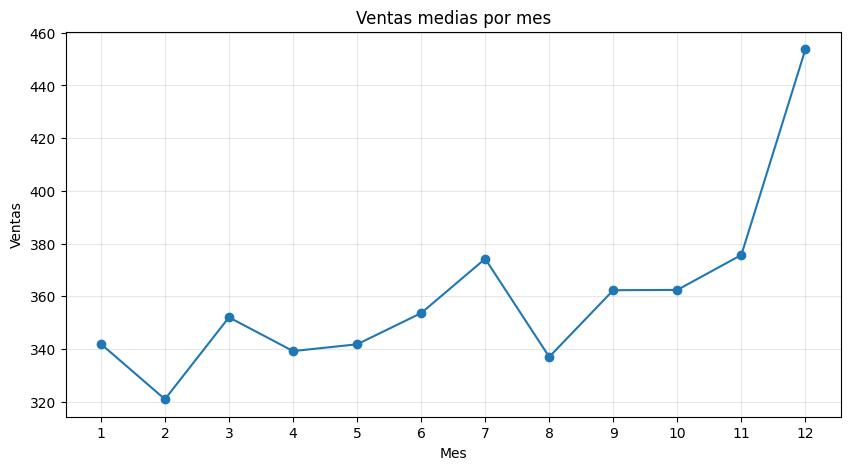

In [ ]:
### Estacionalidad mensual

train["month"] = train["date"].dt.month

monthly_sales = (
    train
    .groupby("month")["sales"]
    .mean()
)

plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.xticks(range(1,13))

plt.title("Ventas medias por mes")

plt.xlabel("Mes")

plt.ylabel("Ventas")

plt.grid(alpha=0.3)


plt.savefig(
    EDA_FIGURES_PATH / "ventas_mes.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

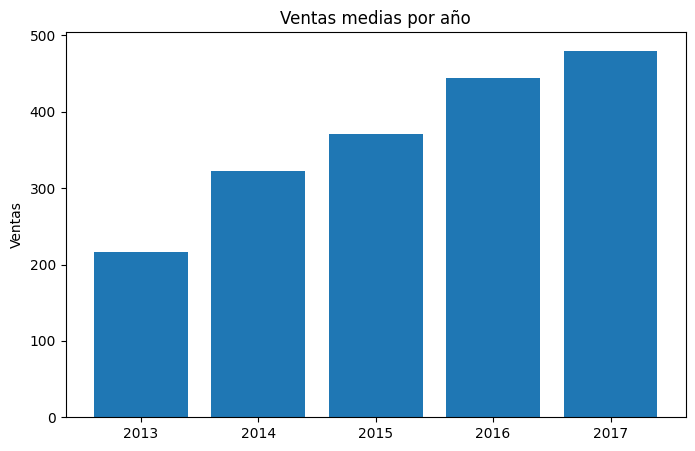

In [18]:
train["year"] = train["date"].dt.year

yearly_sales = (
    train
    .groupby("year")["sales"]
    .mean()
)

plt.figure(figsize=(8,5))

plt.bar(
    yearly_sales.index.astype(str),
    yearly_sales.values
)

plt.title("Ventas medias por año")

plt.ylabel("Ventas")

plt.show()

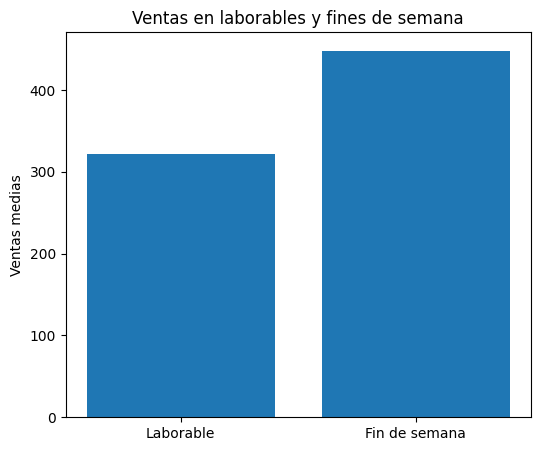

In [ ]:
### Laborales vs fin de semana

train["is_weekend"] = (
    train["date"].dt.weekday >= 5
)

weekend_sales = (
    train
    .groupby("is_weekend")["sales"]
    .mean()
)

weekend_sales.index = [
    "Laborable",
    "Fin de semana"
]

plt.figure(figsize=(6,5))

plt.bar(
    weekend_sales.index,
    weekend_sales.values
)

plt.ylabel("Ventas medias")

plt.title("Ventas en laborables y fines de semana")


plt.savefig(
    EDA_FIGURES_PATH / "laborable_vs_fin_semana.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

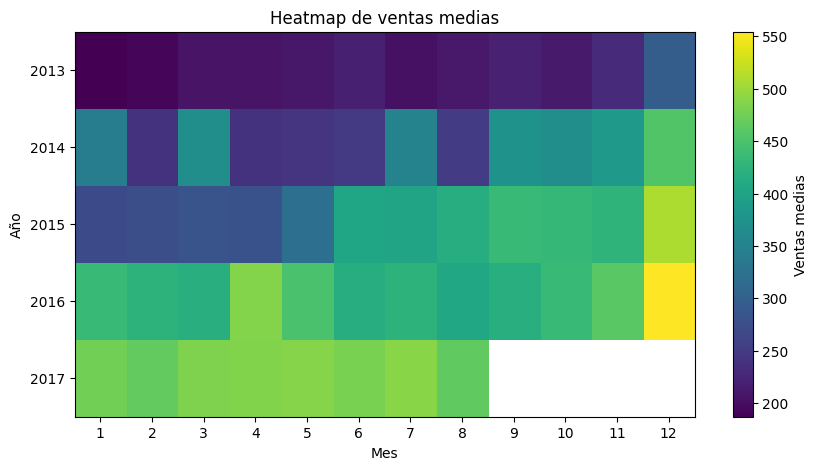

In [ ]:
### Heatmap mes-año

heatmap = train.pivot_table(
    values="sales",
    index=train["date"].dt.year,
    columns=train["date"].dt.month,
    aggfunc="mean"
)

plt.figure(figsize=(10,5))

plt.imshow(
    heatmap,
    aspect="auto"
)

plt.colorbar(label="Ventas medias")

plt.xticks(
    range(12),
    range(1,13)
)

plt.yticks(
    range(len(heatmap.index)),
    heatmap.index
)

plt.xlabel("Mes")

plt.ylabel("Año")

plt.title("Heatmap de ventas medias")


plt.savefig(
    EDA_FIGURES_PATH / "heatmap_mes_anio.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

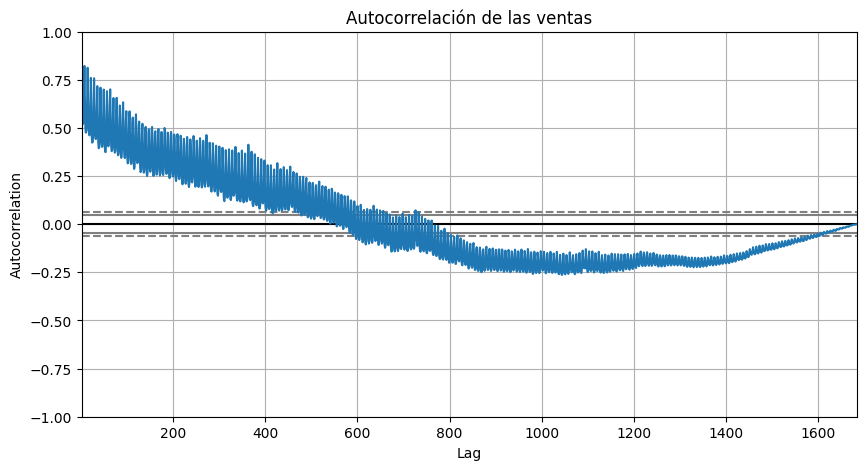

In [ ]:
from pandas.plotting import autocorrelation_plot

plt.figure(figsize=(10,5))

autocorrelation_plot(daily_sales)

plt.title("Autocorrelación de las ventas")


plt.savefig(
    EDA_FIGURES_PATH / "autocorrelacion_ventas.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# 3.3 Análisis por tienda

,Ventas
store_nbr,
44,6.208755e+07
45,5.449801e+07
47,5.094831e+07
3,5.048191e+07
49,4.342010e+07
46,4.189606e+07
48,3.593313e+07
51,3.291149e+07
8,3.049429e+07


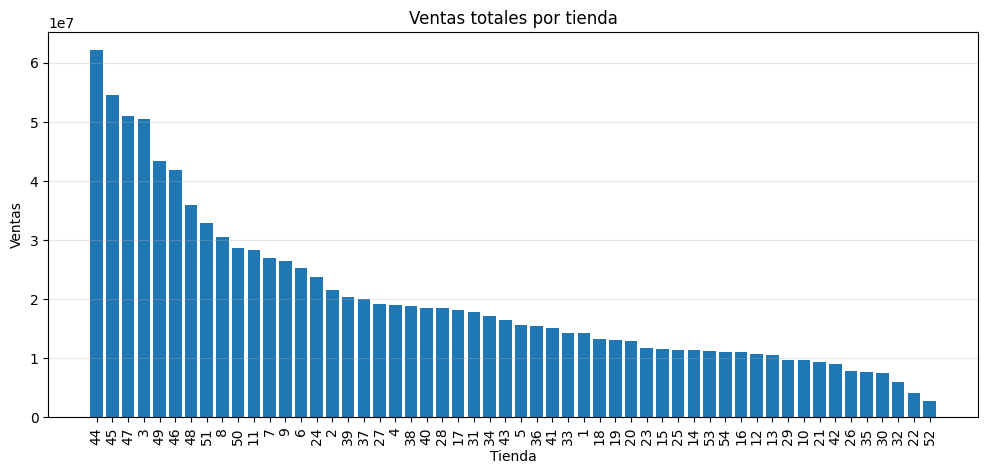

In [ ]:
### Tiendas con mayores y menores ventas

# =============================================================================
# Ventas totales por tienda
# =============================================================================

sales_store = (
    train
    .groupby("store_nbr")["sales"]
    .sum()
    .sort_values(ascending=False)
)

display(sales_store.to_frame(name="Ventas"))

plt.figure(figsize=(12,5))

plt.bar(
    sales_store.index.astype(str),
    sales_store.values
)

plt.title("Ventas totales por tienda")

plt.xlabel("Tienda")

plt.ylabel("Ventas")

plt.xticks(rotation=90)

plt.grid(axis="y", alpha=0.3)


plt.savefig(
    EDA_FIGURES_PATH / "ventas_por_tienda.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

/tmp/ipykernel_20307/1531778701.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


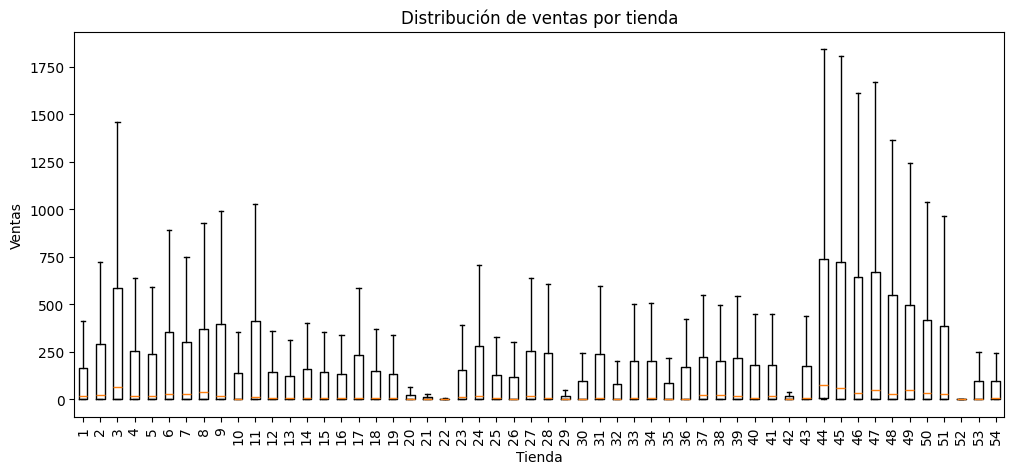

In [23]:
### Variabilidad entre establecimientos

# =============================================================================
# Distribución de ventas por tienda
# =============================================================================

sales_store_mean = (
    train
    .groupby("store_nbr")["sales"]
    .mean()
)

plt.figure(figsize=(12,5))

plt.boxplot(
    [
        train.loc[
            train["store_nbr"] == store,
            "sales"
        ]
        for store in sorted(train["store_nbr"].unique())
    ],
    labels=sorted(train["store_nbr"].unique()),
    showfliers=False
)

plt.title("Distribución de ventas por tienda")

plt.xlabel("Tienda")

plt.ylabel("Ventas")

plt.xticks(rotation=90)

plt.show()

In [24]:
### Ventas según ciudad, provincia, tipo y clúster

train_store = train.merge(
    stores,
    on="store_nbr",
    how="left"
)

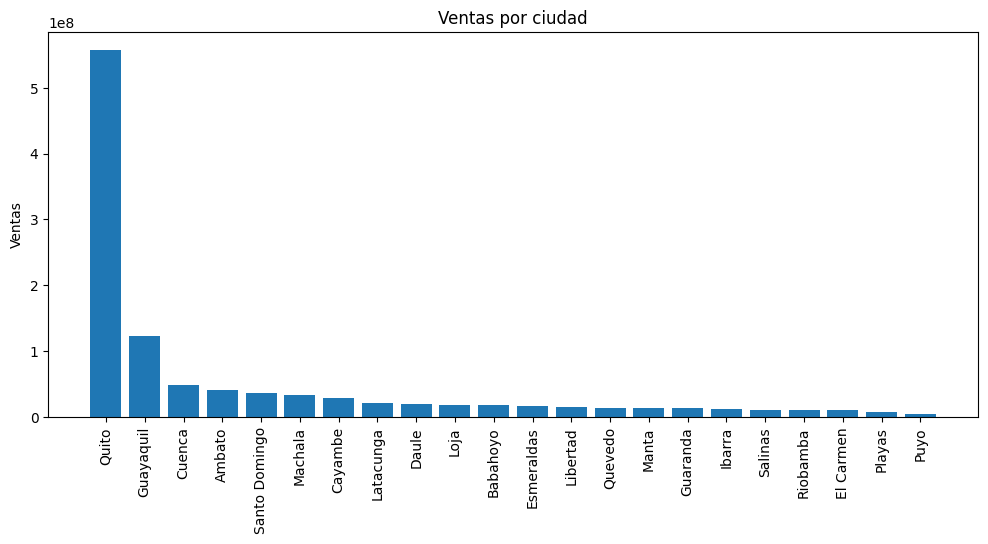

In [ ]:
city_sales = (
    train_store
    .groupby("city")["sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,5))

plt.bar(
    city_sales.index,
    city_sales.values
)

plt.xticks(rotation=90)

plt.title("Ventas por ciudad")

plt.ylabel("Ventas")


plt.savefig(
    EDA_FIGURES_PATH / "ventas_por_ciudad.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

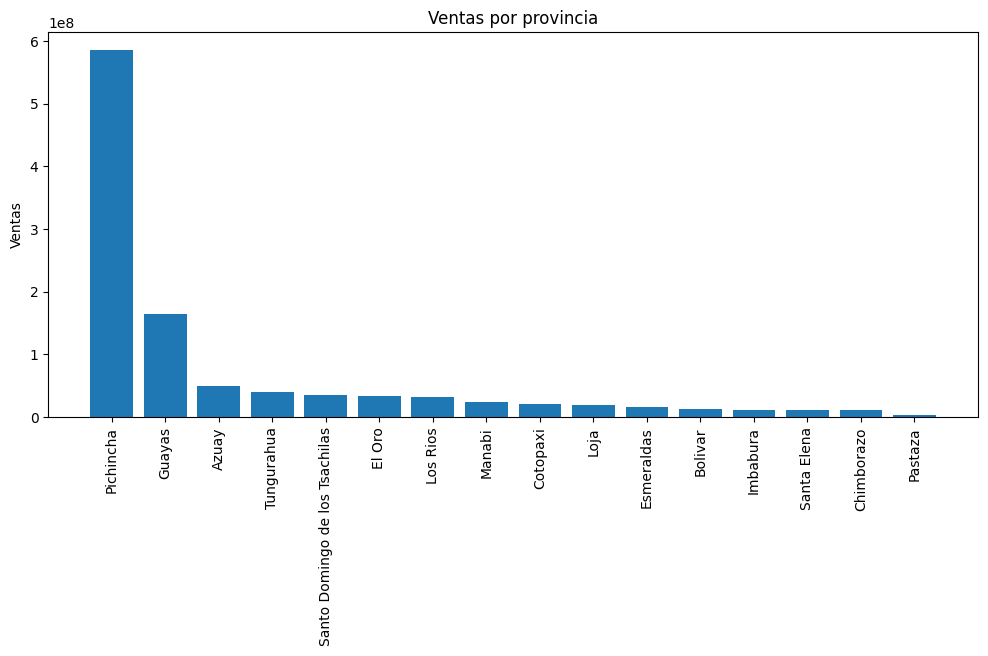

In [26]:
state_sales = (
    train_store
    .groupby("state")["sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,5))

plt.bar(
    state_sales.index,
    state_sales.values
)

plt.xticks(rotation=90)

plt.title("Ventas por provincia")

plt.ylabel("Ventas")

plt.show()

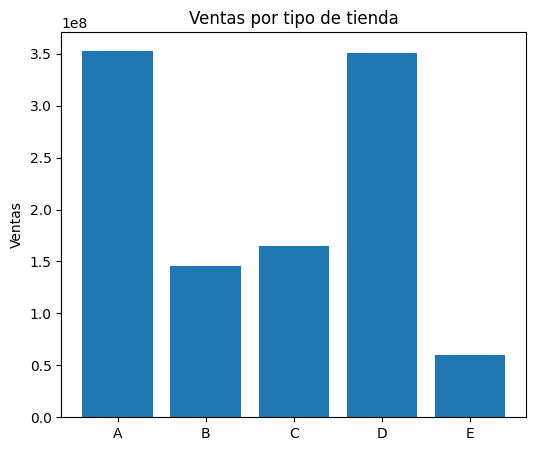

In [ ]:
type_sales = (
    train_store
    .groupby("type")["sales"]
    .sum()
)

plt.figure(figsize=(6,5))

plt.bar(
    type_sales.index,
    type_sales.values
)

plt.title("Ventas por tipo de tienda")

plt.ylabel("Ventas")


plt.savefig(
    EDA_FIGURES_PATH / "ventas_tipo_tienda.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

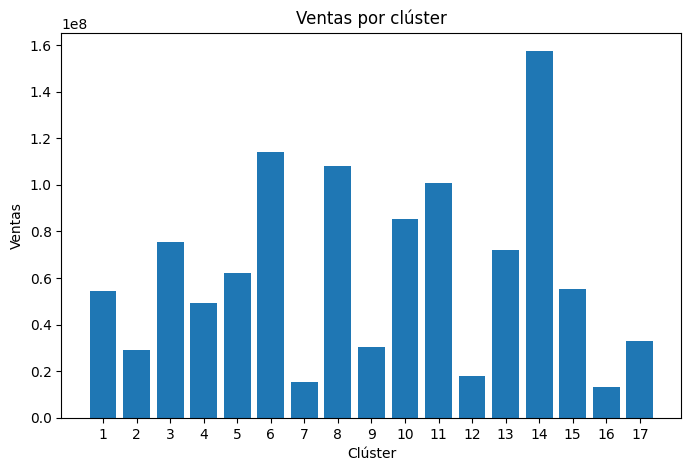

In [28]:
cluster_sales = (
    train_store
    .groupby("cluster")["sales"]
    .sum()
)

plt.figure(figsize=(8,5))

plt.bar(
    cluster_sales.index.astype(str),
    cluster_sales.values
)

plt.title("Ventas por clúster")

plt.xlabel("Clúster")

plt.ylabel("Ventas")

plt.show()

In [29]:
### Relación entre transacciones y ventas

sales_transactions = (
    train
    .groupby(["date","store_nbr"])["sales"]
    .sum()
    .reset_index()
)

sales_transactions = sales_transactions.merge(
    transactions,
    on=["date","store_nbr"],
    how="inner"
)

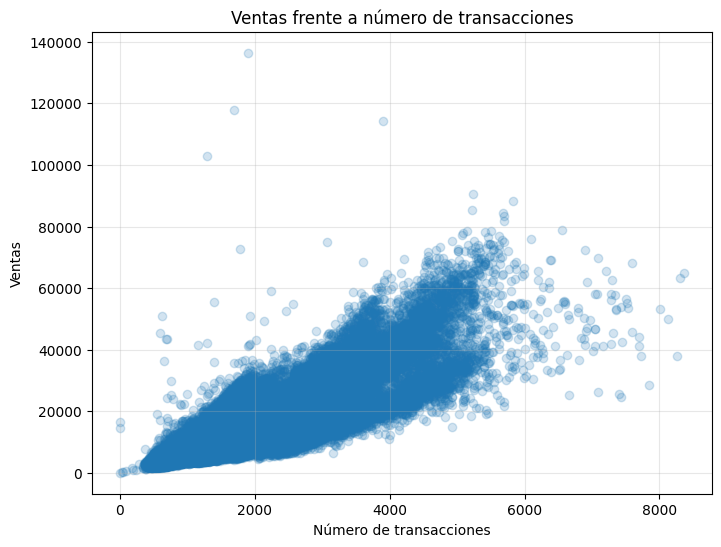

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    sales_transactions["transactions"],
    sales_transactions["sales"],
    alpha=0.2
)

plt.xlabel("Número de transacciones")

plt.ylabel("Ventas")

plt.title("Ventas frente a número de transacciones")

plt.grid(alpha=0.3)


plt.savefig(
    EDA_FIGURES_PATH / "ventas_vs_transacciones.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [31]:
corr = sales_transactions["transactions"].corr(
    sales_transactions["sales"]
)

print(f"Correlación de Pearson: {corr:.3f}")

Correlación de Pearson: 0.837


# 3.4 Análisis por familia de productos

,Ventas
family,
GROCERY I,3.434627e+08
BEVERAGES,2.169545e+08
PRODUCE,1.227047e+08
CLEANING,9.752129e+07
DAIRY,6.448771e+07
BREAD/BAKERY,4.213395e+07
POULTRY,3.187600e+07
MEATS,3.108647e+07
PERSONAL CARE,2.459205e+07


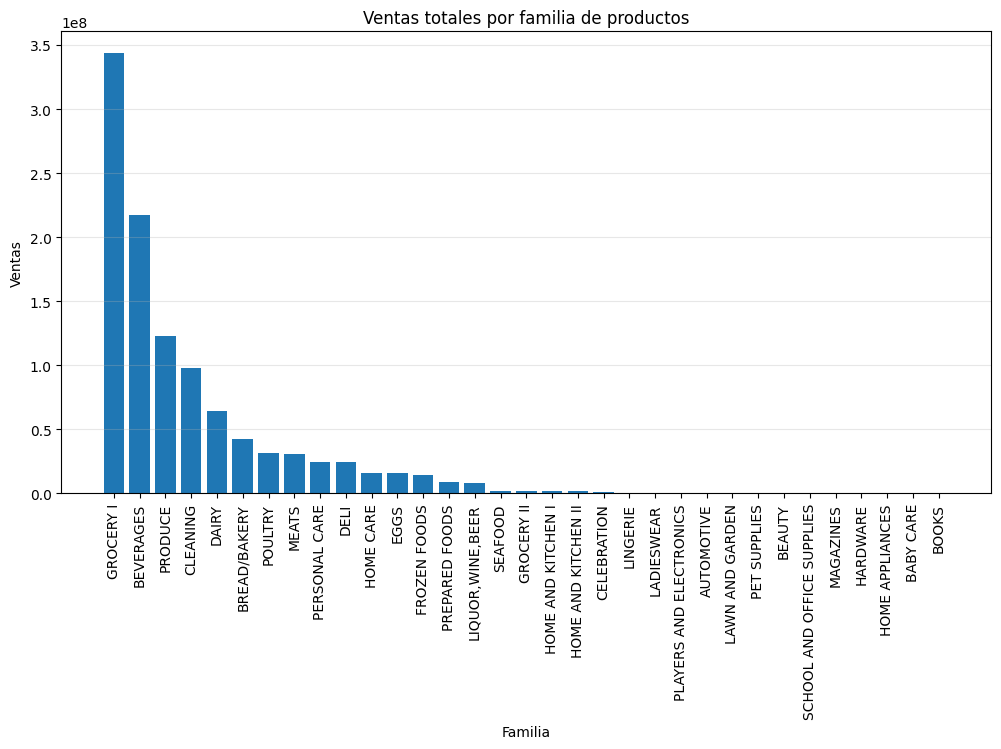

In [ ]:
# =============================================================================
# Ventas totales por familia
# =============================================================================

family_sales = (
    train
    .groupby("family")["sales"]
    .sum()
    .sort_values(ascending=False)
)

display(family_sales.to_frame(name="Ventas"))

plt.figure(figsize=(12,6))

plt.bar(
    family_sales.index,
    family_sales.values
)

plt.title("Ventas totales por familia de productos")

plt.xlabel("Familia")

plt.ylabel("Ventas")

plt.xticks(rotation=90)

plt.grid(axis="y", alpha=0.3)


plt.savefig(
    EDA_FIGURES_PATH / "ventas_por_familia.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

,Desviación estándar
family,
GROCERY I,2874.208845
BEVERAGES,2307.882305
PRODUCE,2186.481332
CLEANING,734.681493
DAIRY,671.949638
MEATS,455.908498
POULTRY,400.511631
BREAD/BAKERY,368.246367
FROZEN FOODS,324.971305


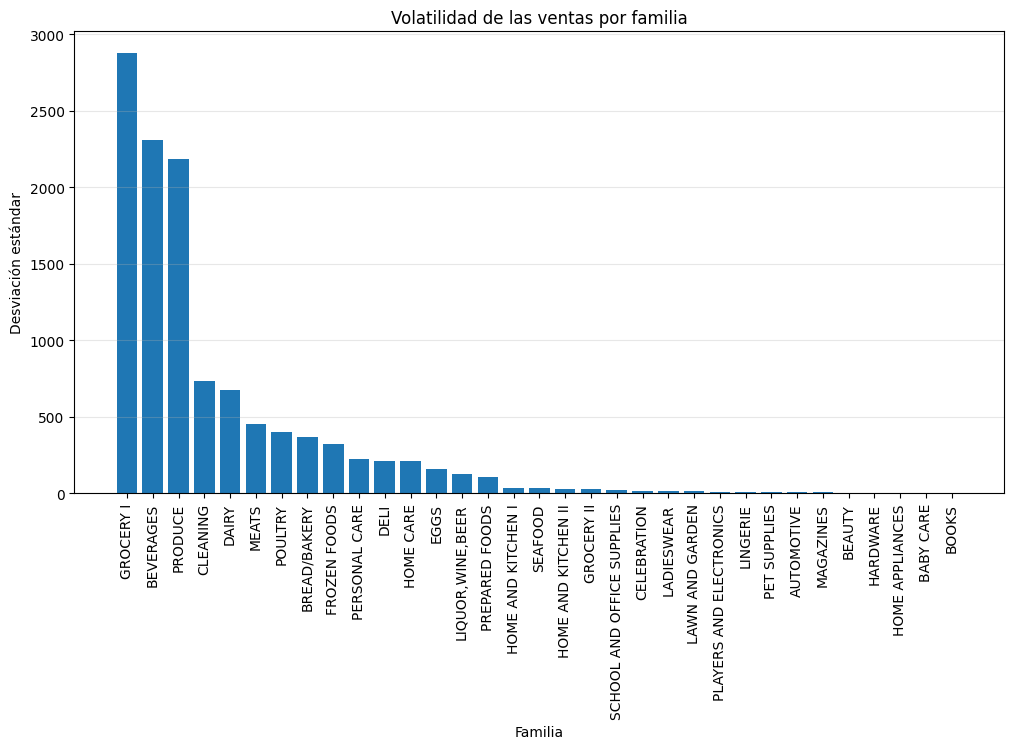

In [ ]:
# =============================================================================
# Volatilidad por familia
# =============================================================================

family_std = (
    train
    .groupby("family")["sales"]
    .std()
    .sort_values(ascending=False)
)

display(family_std.to_frame(name="Desviación estándar"))

plt.figure(figsize=(12,6))

plt.bar(
    family_std.index,
    family_std.values
)

plt.title("Volatilidad de las ventas por familia")

plt.xlabel("Familia")

plt.ylabel("Desviación estándar")

plt.xticks(rotation=90)

plt.grid(axis="y", alpha=0.3)


plt.savefig(
    EDA_FIGURES_PATH / "volatilidad_familia.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

,% ventas = 0
family,
BOOKS,96.955001
BABY CARE,94.131037
SCHOOL AND OFFICE SUPPLIES,74.082871
HOME APPLIANCES,73.517639
LADIESWEAR,59.846485
MAGAZINES,56.538665
PET SUPPLIES,54.615334
HARDWARE,47.862233
LAWN AND GARDEN,46.784552


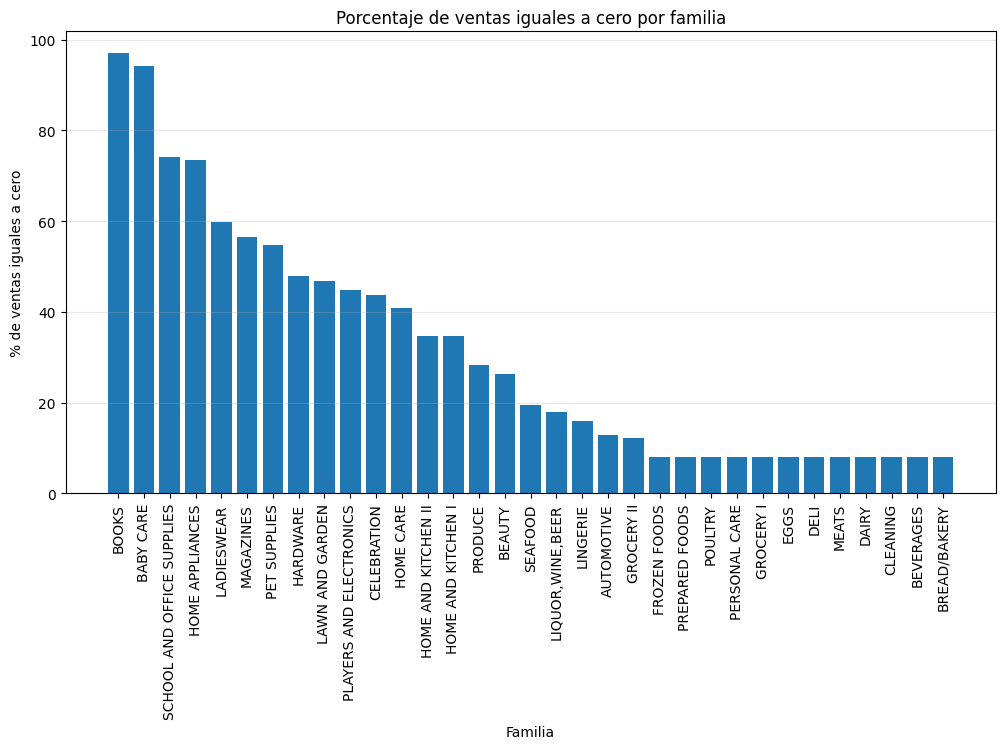

In [ ]:
# =============================================================================
# Porcentaje de ventas iguales a cero por familia
# =============================================================================

zero_sales = (
    train
    .groupby("family")["sales"]
    .apply(lambda x: (x == 0).mean() * 100)
    .sort_values(ascending=False)
)

display(zero_sales.to_frame(name="% ventas = 0"))

plt.figure(figsize=(12,6))

plt.bar(
    zero_sales.index,
    zero_sales.values
)

plt.title("Porcentaje de ventas iguales a cero por familia")

plt.xlabel("Familia")

plt.ylabel("% de ventas iguales a cero")

plt.xticks(rotation=90)

plt.grid(axis="y", alpha=0.3)


plt.savefig(
    EDA_FIGURES_PATH / "ventas_cero_familia.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

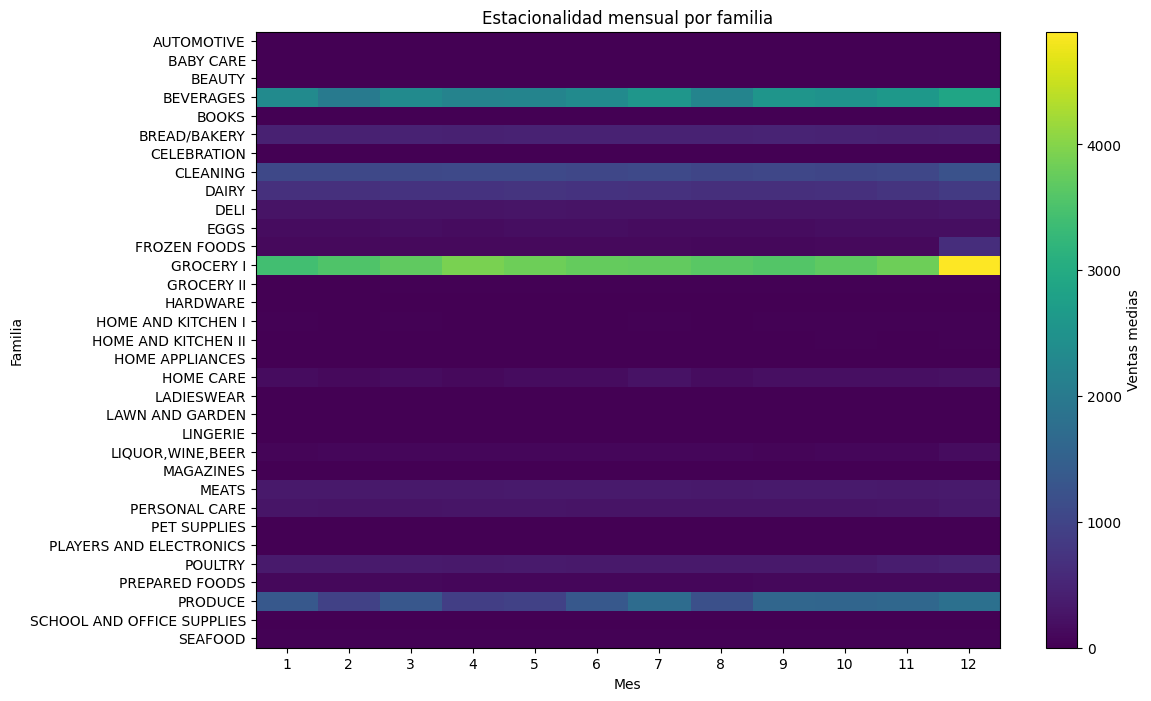

In [ ]:
# =============================================================================
# Estacionalidad mensual por familia
# =============================================================================

train["month"] = train["date"].dt.month

seasonality = (
    train
    .pivot_table(
        values="sales",
        index="family",
        columns="month",
        aggfunc="mean"
    )
)

plt.figure(figsize=(12,8))

plt.imshow(
    seasonality,
    aspect="auto"
)

plt.colorbar(label="Ventas medias")

plt.xticks(
    range(12),
    range(1,13)
)

plt.yticks(
    range(len(seasonality.index)),
    seasonality.index
)

plt.xlabel("Mes")

plt.ylabel("Familia")

plt.title("Estacionalidad mensual por familia")


plt.savefig(
    EDA_FIGURES_PATH / "estacionalidad_familia.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

,Sin promoción,Con promoción,Incremento
family,,,
BEVERAGES,1292.272591,3215.498308,1923.225717
GROCERY I,2717.720813,4411.003431,1693.282618
PRODUCE,792.101911,2438.220197,1646.118286
DAIRY,479.811128,933.341720,453.530592
CLEANING,868.378326,1240.210741,371.832415
HOME CARE,101.956009,309.444864,207.488856
BREAD/BAKERY,379.513249,575.485296,195.972047
POULTRY,313.334513,485.006113,171.671600
MEATS,303.081088,467.301631,164.220543


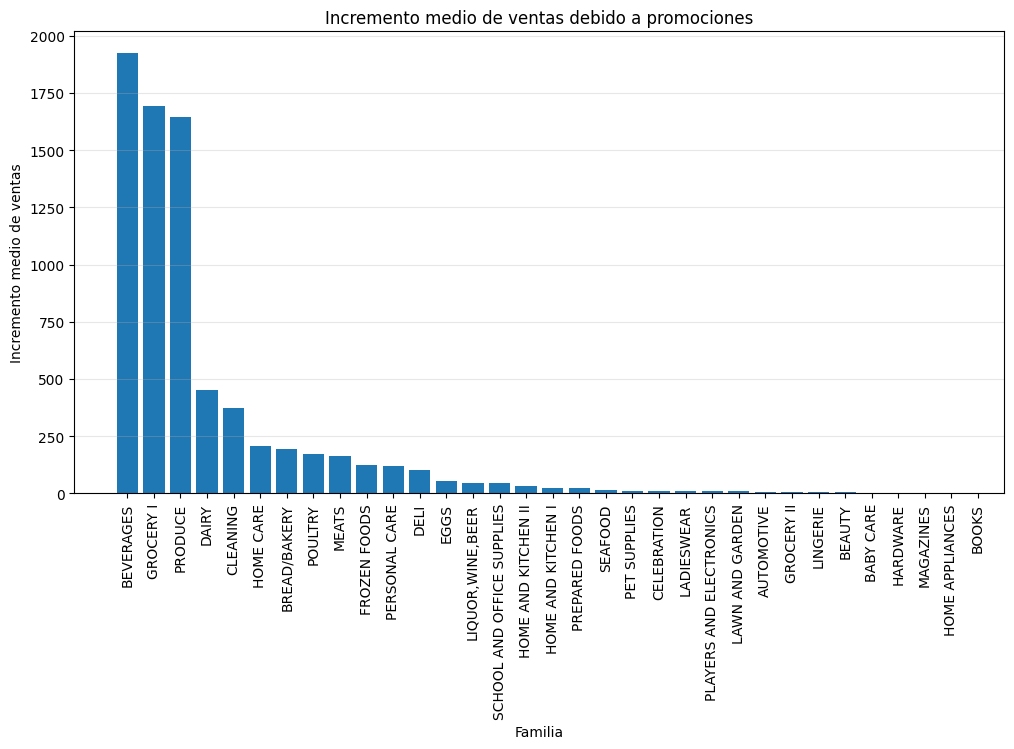

In [ ]:
# =============================================================================
# Sensibilidad a promociones
# =============================================================================

promo_effect = (
    train
    .assign(
        promotion=train["onpromotion"] > 0
    )
    .groupby(["family","promotion"])["sales"]
    .mean()
    .unstack()
)

promo_effect.columns = [
    "Sin promoción",
    "Con promoción"
]

promo_effect["Incremento"] = (
    promo_effect["Con promoción"] -
    promo_effect["Sin promoción"]
)

promo_effect = promo_effect.sort_values(
    "Incremento",
    ascending=False
)

display(promo_effect)

plt.figure(figsize=(12,6))

plt.bar(
    promo_effect.index,
    promo_effect["Incremento"]
)

plt.title("Incremento medio de ventas debido a promociones")

plt.xlabel("Familia")

plt.ylabel("Incremento medio de ventas")

plt.xticks(rotation=90)

plt.grid(axis="y", alpha=0.3)


plt.savefig(
    EDA_FIGURES_PATH / "sensibilidad_promociones_familia.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [37]:
family_mean = (
    train
    .groupby("family")["sales"]
    .mean()
    .sort_values(ascending=False)
)

# 3.5 Análisis de promociones

In [38]:
# =============================================================================
# Relación entre promociones y ventas
# =============================================================================

correlation = train["onpromotion"].corr(train["sales"])

print(f"Correlación de Pearson: {correlation:.3f}")

Correlación de Pearson: 0.428


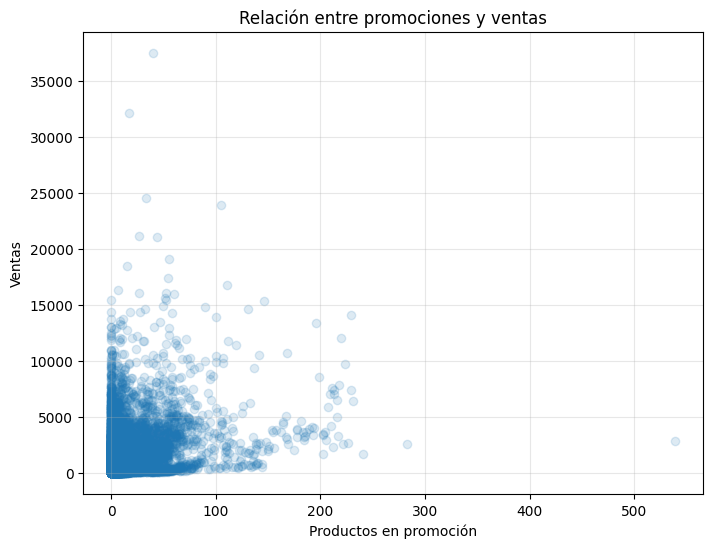

In [39]:
sample = train.sample(
    n=50000,
    random_state=42
)

plt.figure(figsize=(8,6))

plt.scatter(
    sample["onpromotion"],
    sample["sales"],
    alpha=0.15
)

plt.xlabel("Productos en promoción")

plt.ylabel("Ventas")

plt.title("Relación entre promociones y ventas")

plt.grid(alpha=0.3)

plt.show()

Sin promoción     158.246681
Con promoción    1137.693730
Name: sales, dtype: float64

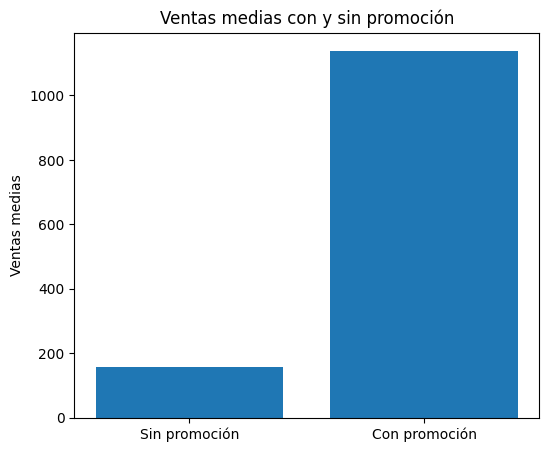

In [ ]:
promotion_sales = (
    train
    .assign(
        promotion=train["onpromotion"] > 0
    )
    .groupby("promotion")["sales"]
    .mean()
)

promotion_sales.index = [
    "Sin promoción",
    "Con promoción"
]

display(promotion_sales)

plt.figure(figsize=(6,5))

plt.bar(
    promotion_sales.index,
    promotion_sales.values
)

plt.ylabel("Ventas medias")

plt.title("Ventas medias con y sin promoción")


plt.savefig(
    EDA_FIGURES_PATH / "promocion_vs_sin_promocion.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [ ]:
family_promo = promo_effect

missing_family = family_promo[
    family_promo["Con promoción"].isna()
].index.tolist()

if missing_family:
    print(
        f"Nota: {missing_family} nunca presenta onpromotion > 0 "
        "en el histórico, por lo que no se puede calcular su venta "
        "media 'Con promoción'."
    )

display(family_promo)

Nota: ['BOOKS'] nunca presenta onpromotion > 0 en el histórico, por lo que no se puede calcular su venta media 'Con promoción'.


,Sin promoción,Con promoción,Incremento
family,,,
BEVERAGES,1292.272591,3215.498308,1923.225717
GROCERY I,2717.720813,4411.003431,1693.282618
PRODUCE,792.101911,2438.220197,1646.118286
DAIRY,479.811128,933.341720,453.530592
CLEANING,868.378326,1240.210741,371.832415
HOME CARE,101.956009,309.444864,207.488856
BREAD/BAKERY,379.513249,575.485296,195.972047
POULTRY,313.334513,485.006113,171.671600
MEATS,303.081088,467.301631,164.220543


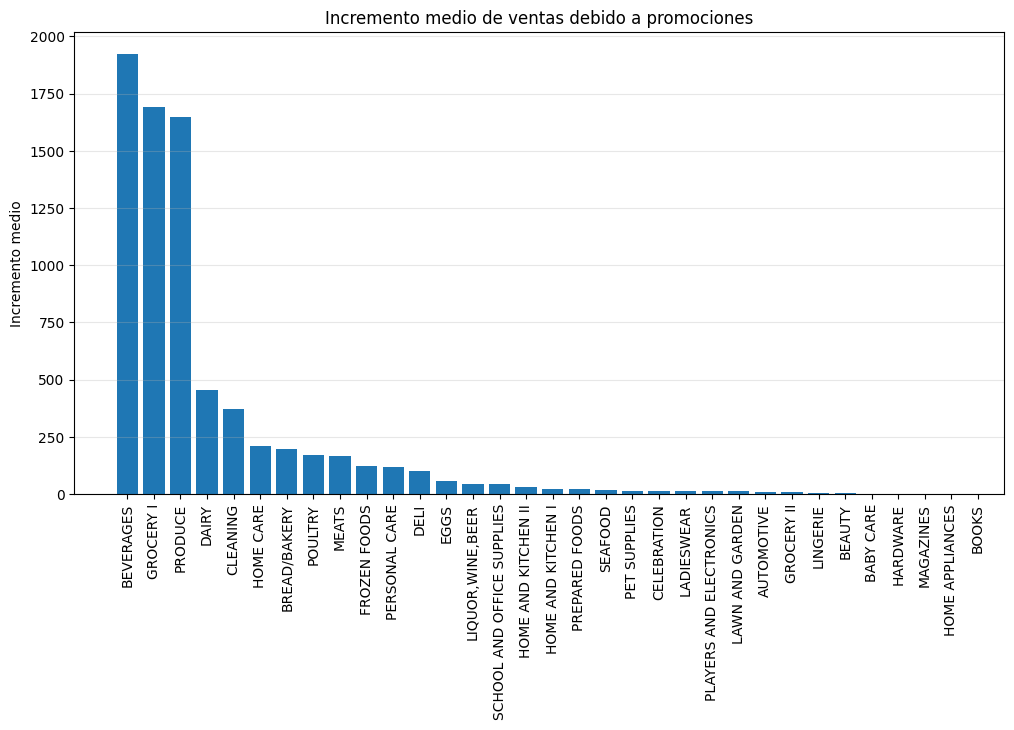

In [42]:
plt.figure(figsize=(12,6))

plt.bar(
    family_promo.index,
    family_promo["Incremento"]
)

plt.xticks(rotation=90)

plt.ylabel("Incremento medio")

plt.title("Incremento medio de ventas debido a promociones")

plt.grid(axis="y", alpha=0.3)

plt.show()

### Posibles efectos retardados

In [43]:
daily = (
    train
    .groupby("date")
    .agg({
        "sales":"sum",
        "onpromotion":"sum"
    })
)

In [44]:
for lag in [1, 2, 3, 7]:

    daily[f"promo_lag_{lag}"] = (
        daily["onpromotion"]
        .shift(lag)
    )

In [45]:
lag_corr = {}

for lag in [0,1,2,3,7]:

    if lag == 0:
        corr = daily["sales"].corr(
            daily["onpromotion"]
        )

    else:
        corr = daily["sales"].corr(
            daily[f"promo_lag_{lag}"]
        )

    lag_corr[lag] = corr

lag_corr = pd.Series(lag_corr)

display(lag_corr)

0    0.574943
1    0.573480
2    0.627467
3    0.653043
7    0.556871
dtype: float64

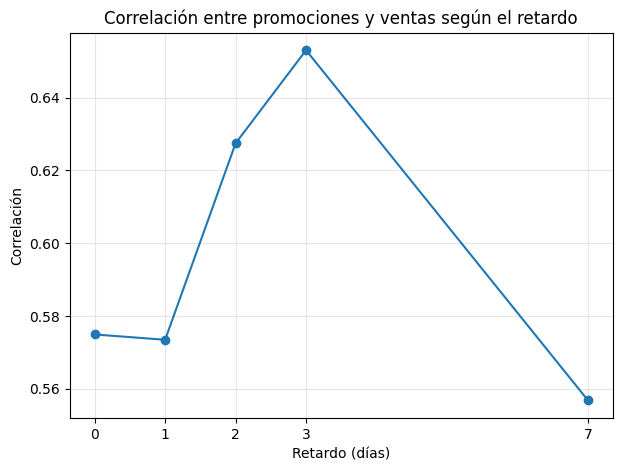

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(
    lag_corr.index,
    lag_corr.values,
    marker="o"
)

plt.xticks([0,1,2,3,7])

plt.xlabel("Retardo (días)")

plt.ylabel("Correlación")

plt.title("Correlación entre promociones y ventas según el retardo")

plt.grid(alpha=0.3)


plt.savefig(
    EDA_FIGURES_PATH / "retardo_promociones.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [47]:
pearson = train["sales"].corr(train["onpromotion"], method="pearson")
spearman = train["sales"].corr(train["onpromotion"], method="spearman")

print(f"Pearson : {pearson:.3f}")
print(f"Spearman: {spearman:.3f}")

Pearson : 0.428
Spearman: 0.538


# 3.6 Análisis de festivos y eventos

In [48]:
# =============================================================================
# Comprobación de fechas duplicadas
# =============================================================================

duplicated_dates = holidays["date"].duplicated().sum()

print(f"Fechas duplicadas: {duplicated_dates}")

display(
    holidays["date"]
    .value_counts()
    .head(10)
)

Fechas duplicadas: 38


date
2014-06-25    4
2017-06-25    3
2016-06-25    3
2015-06-25    3
2013-06-25    3
2012-06-25    3
2014-12-26    2
2015-12-22    2
2012-12-22    2
2012-12-24    2
Name: count, dtype: int64

In [49]:
# =============================================================================
# Crear un calendario simplificado de festivos
# =============================================================================

holidays_simple = (
    holidays
    .groupby("date")
    .agg({
        "type":"first",
        "locale":"first",
        "transferred":"max"
    })
    .reset_index()
)

holidays_simple["holiday"] = True

In [50]:
train_holidays = train.merge(
    holidays_simple,
    on="date",
    how="left"
)

train_holidays["holiday"] = (
    train_holidays["holiday"]
    .fillna(False)
)

/tmp/ipykernel_20307/2773279936.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


Día normal    352.159181
Festivo       389.692123
Name: sales, dtype: float64

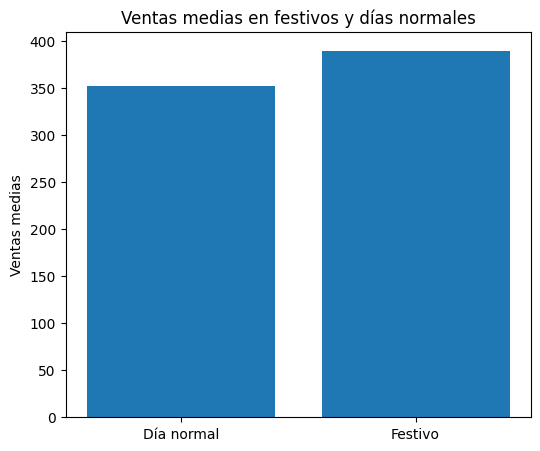

In [ ]:
### Ventas en festivos frente a días normales

holiday_sales = (
    train_holidays
    .groupby("holiday")["sales"]
    .mean()
)

holiday_sales.index = [
    "Día normal",
    "Festivo"
]

display(holiday_sales)

plt.figure(figsize=(6,5))

plt.bar(
    holiday_sales.index,
    holiday_sales.values
)

plt.ylabel("Ventas medias")

plt.title("Ventas medias en festivos y días normales")


plt.savefig(
    EDA_FIGURES_PATH / "festivo_vs_normal.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

type
Additional    485.410252
Transfer      466.747805
Bridge        446.750854
Event         423.368077
Holiday       352.430015
Work Day      334.753194
Name: sales, dtype: float64

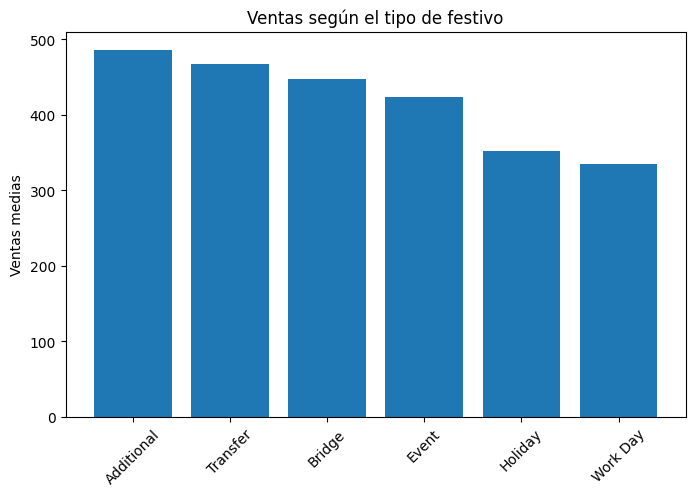

In [ ]:
### Tipo de festivo

type_sales = (
    train_holidays
    .groupby("type")["sales"]
    .mean()
    .sort_values(ascending=False)
)

display(type_sales)

plt.figure(figsize=(8,5))

plt.bar(
    type_sales.index.astype(str),
    type_sales.values
)

plt.ylabel("Ventas medias")

plt.title("Ventas según el tipo de festivo")

plt.xticks(rotation=45)


plt.savefig(
    EDA_FIGURES_PATH / "ventas_tipo_festivo.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

locale
Local       356.750042
National    413.072143
Regional    399.523285
Name: sales, dtype: float64

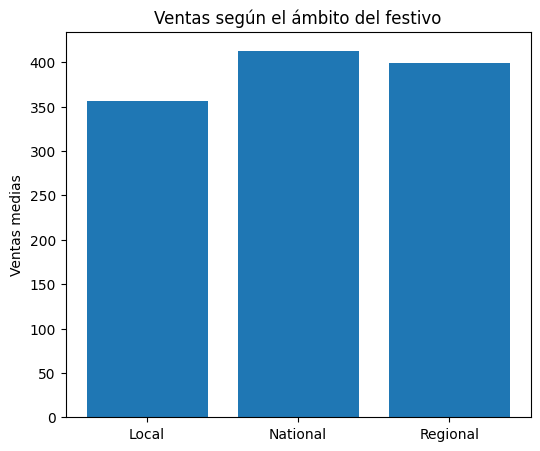

In [53]:
### Ámbito geográfico

locale_sales = (
    train_holidays
    .groupby("locale")["sales"]
    .mean()
)

display(locale_sales)

plt.figure(figsize=(6,5))

plt.bar(
    locale_sales.index.astype(str),
    locale_sales.values
)

plt.ylabel("Ventas medias")

plt.title("Ventas según el ámbito del festivo")

plt.show()

No trasladado    392.585897
Trasladado       311.560228
Name: sales, dtype: float64

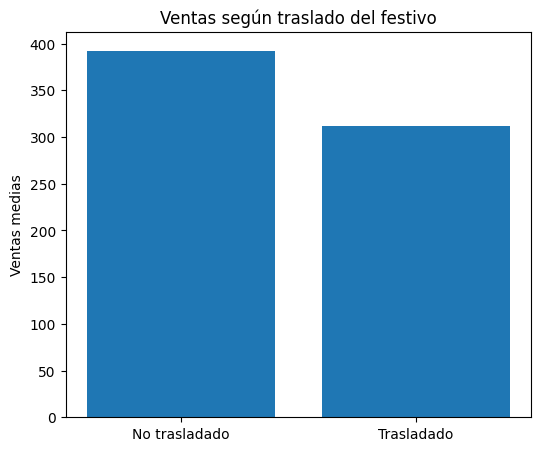

In [ ]:
### Festivos trasladados

transferred_sales = (
    train_holidays
    .groupby("transferred")["sales"]
    .mean()
)

transferred_sales.index = [
    "No trasladado",
    "Trasladado"
]

display(transferred_sales)

plt.figure(figsize=(6,5))

plt.bar(
    transferred_sales.index,
    transferred_sales.values
)

plt.ylabel("Ventas medias")

plt.title("Ventas según traslado del festivo")


plt.savefig(
    EDA_FIGURES_PATH / "festivos_trasladados.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [55]:
### Días adicionales y puentes

special_days = (
    train_holidays[
        train_holidays["type"].isin(
            ["Bridge","Additional"]
        )
    ]
)

display(
    special_days["type"]
    .value_counts()
)

type
Additional    64152
Bridge         5346
Name: count, dtype: int64

type
Additional    485.410252
Bridge        446.750854
Name: sales, dtype: float64

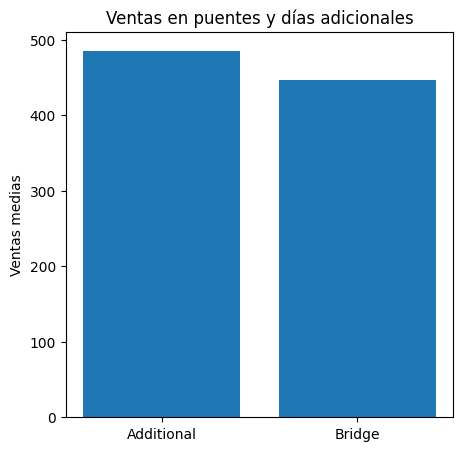

In [56]:
bridge_sales = (
    special_days
    .groupby("type")["sales"]
    .mean()
)

display(bridge_sales)

plt.figure(figsize=(5,5))

plt.bar(
    bridge_sales.index,
    bridge_sales.values
)

plt.ylabel("Ventas medias")

plt.title("Ventas en puentes y días adicionales")

plt.show()

In [57]:
holiday_dates = set(holidays_simple["date"])

In [58]:
analysis = (
    train
    .groupby("date")["sales"]
    .sum()
    .reset_index()
)

analysis["holiday"] = analysis["date"].isin(holiday_dates)

analysis["before_holiday"] = (
    analysis["date"] + pd.Timedelta(days=1)
).isin(holiday_dates)

analysis["after_holiday"] = (
    analysis["date"] - pd.Timedelta(days=1)
).isin(holiday_dates)

,Ventas
Normal,625106.171904
Día anterior,690081.389987
Festivo,694431.362793
Día posterior,689810.693680


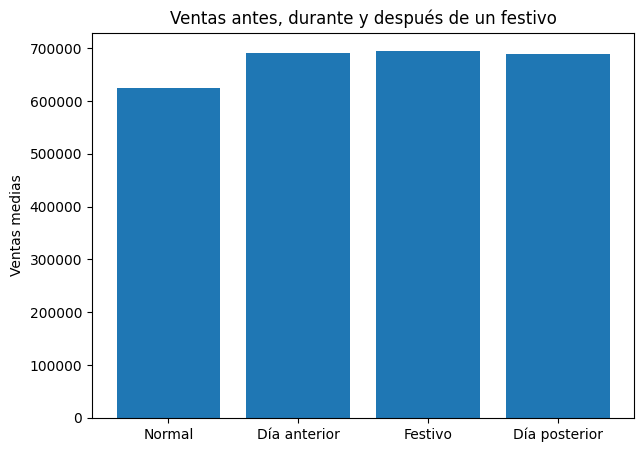

In [ ]:
effect = pd.DataFrame({
    "Normal":
        analysis.loc[
            ~(analysis["holiday"] |
              analysis["before_holiday"] |
              analysis["after_holiday"]),
            "sales"
        ].mean(),

    "Día anterior":
        analysis.loc[
            analysis["before_holiday"],
            "sales"
        ].mean(),

    "Festivo":
        analysis.loc[
            analysis["holiday"],
            "sales"
        ].mean(),

    "Día posterior":
        analysis.loc[
            analysis["after_holiday"],
            "sales"
        ].mean()

}, index=[0]).T

effect.columns = ["Ventas"]

display(effect)

plt.figure(figsize=(7,5))

plt.bar(
    effect.index,
    effect["Ventas"]
)

plt.ylabel("Ventas medias")

plt.title("Ventas antes, durante y después de un festivo")


plt.savefig(
    EDA_FIGURES_PATH / "efecto_temporal_festivo.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# 3.7 Análisis del precio del petróleo

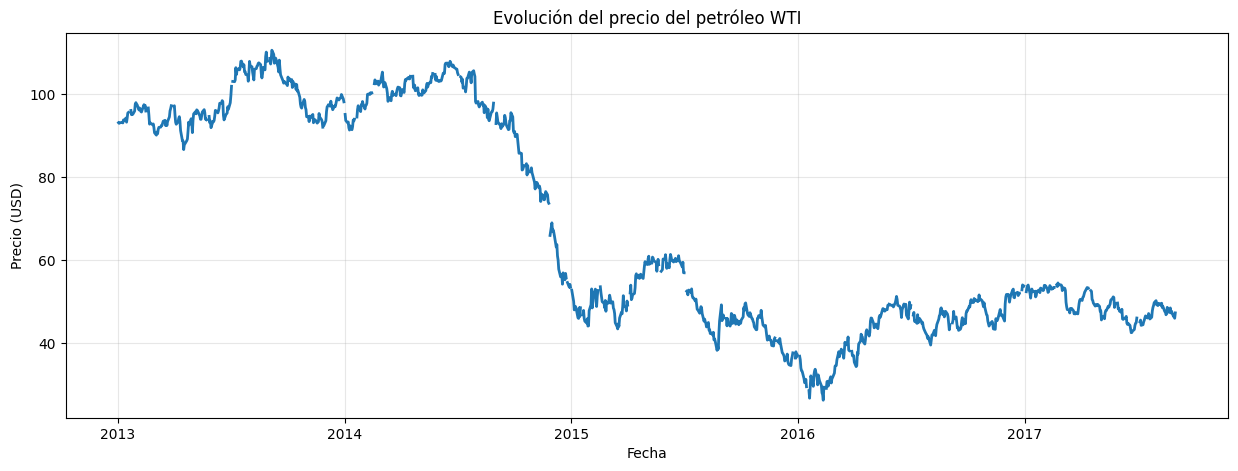

In [ ]:
# =============================================================================
# Evolución temporal del precio del petróleo
# =============================================================================

plt.figure(figsize=(15,5))

plt.plot(
    oil["date"],
    oil["dcoilwtico"],
    linewidth=2
)

plt.title("Evolución del precio del petróleo WTI")

plt.xlabel("Fecha")

plt.ylabel("Precio (USD)")

plt.grid(alpha=0.3)


plt.savefig(
    EDA_FIGURES_PATH / "evolucion_petroleo.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [61]:
# =============================================================================
# Valores ausentes
# =============================================================================

missing = oil["dcoilwtico"].isna().sum()

percentage = missing / len(oil) * 100

print(f"Valores ausentes: {missing}")

print(f"Porcentaje: {percentage:.2f}%")

Valores ausentes: 43
Porcentaje: 3.53%


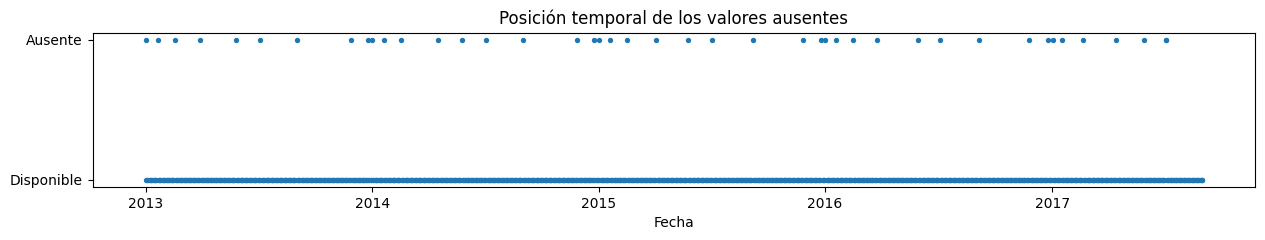

In [ ]:
plt.figure(figsize=(15,2))

plt.scatter(
    oil["date"],
    oil["dcoilwtico"].isna(),
    s=8
)

plt.title("Posición temporal de los valores ausentes")

plt.xlabel("Fecha")

plt.yticks([0,1],["Disponible","Ausente"])

plt.show()

In [ ]:
# =============================================================================
# Ventas diarias
# =============================================================================

daily_sales = (
    train
    .groupby("date")["sales"]
    .sum()
    .reset_index()
)

In [ ]:
sales_oil = (
    daily_sales
    .merge(
        oil,
        on="date",
        how="left"
    )
)

In [65]:
# =============================================================================
# Correlación entre petróleo y ventas
# =============================================================================

pearson = sales_oil["sales"].corr(
    sales_oil["dcoilwtico"],
    method="pearson"
)

spearman = sales_oil["sales"].corr(
    sales_oil["dcoilwtico"],
    method="spearman"
)

print(f"Pearson : {pearson:.3f}")

print(f"Spearman: {spearman:.3f}")

Pearson : -0.705
Spearman: -0.660


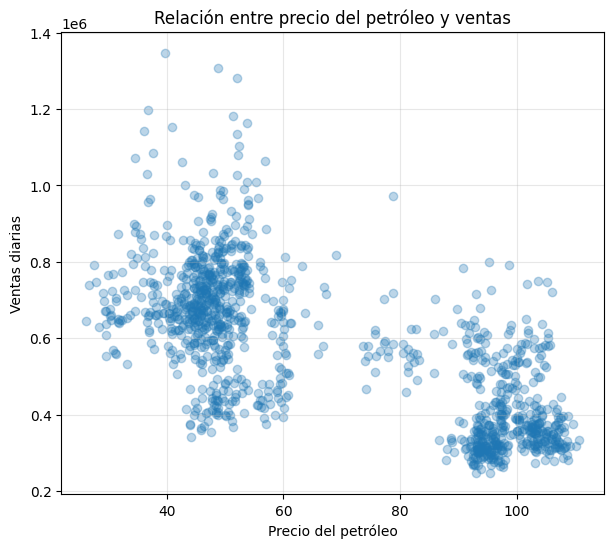

In [ ]:
### Diagrama de dispersión

plt.figure(figsize=(7,6))

plt.scatter(
    sales_oil["dcoilwtico"],
    sales_oil["sales"],
    alpha=0.3
)

plt.xlabel("Precio del petróleo")

plt.ylabel("Ventas diarias")

plt.title("Relación entre precio del petróleo y ventas")

plt.grid(alpha=0.3)


plt.savefig(
    EDA_FIGURES_PATH / "petroleo_vs_ventas.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [ ]:
# =============================================================================
# Correlaciones con retardos
# =============================================================================

lags = [1, 3, 7, 14, 30]

lag_corr = {}

for lag in lags:

    sales_oil[f"oil_lag_{lag}"] = (
        sales_oil["dcoilwtico"]
        .shift(lag)
    )

    lag_corr[lag] = (
        sales_oil["sales"]
        .corr(
            sales_oil[f"oil_lag_{lag}"]
        )
    )

lag_corr = pd.Series(lag_corr)

display(lag_corr)

1    -0.648993
3    -0.612801
7    -0.688843
14   -0.676846
30   -0.586778
dtype: float64

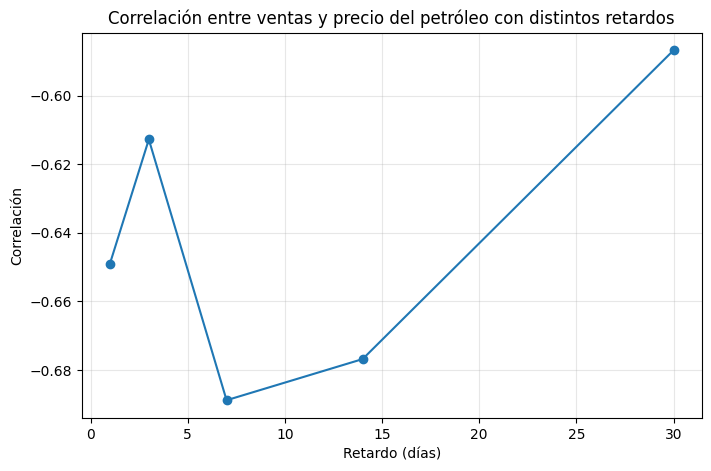

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    lag_corr.index,
    lag_corr.values,
    marker="o"
)

plt.xlabel("Retardo (días)")

plt.ylabel("Correlación")

plt.title("Correlación entre ventas y precio del petróleo con distintos retardos")

plt.grid(alpha=0.3)

plt.savefig(
    EDA_FIGURES_PATH / "retardo_petroleo.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

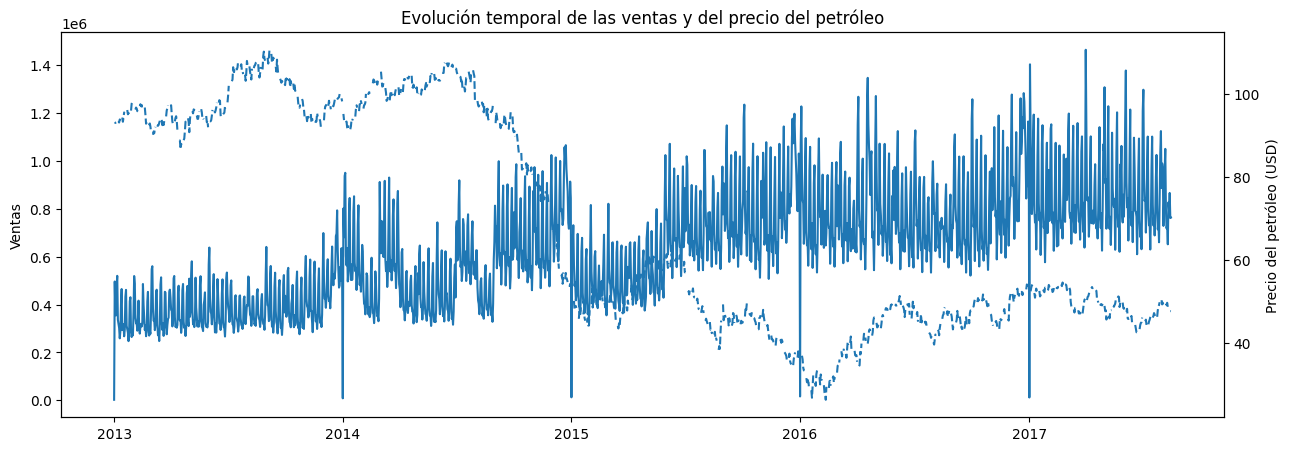

In [69]:
fig, ax1 = plt.subplots(figsize=(15,5))

ax1.plot(
    sales_oil["date"],
    sales_oil["sales"],
    label="Ventas"
)

ax1.set_ylabel("Ventas")

ax2 = ax1.twinx()

ax2.plot(
    sales_oil["date"],
    sales_oil["dcoilwtico"],
    linestyle="--",
    label="Petróleo"
)

ax2.set_ylabel("Precio del petróleo (USD)")

plt.title("Evolución temporal de las ventas y del precio del petróleo")

plt.show()